/home/namithk/miniconda3/envs/eew/lib/python3.9/site-packages/seisbench/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026-05-06 00:29:10,407 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.



=== METRICS ===
Precision: 1.0
Recall: 0.9473684210526315
ROC-AUC: 1.0
PR-AUC: 1.0

=== RANDOM SAMPLE VISUALIZATION ===

Sample 0
Detection Prob: 1.0000
P pred: 702, P true: 1000
S pred: 1830, S true: 1811


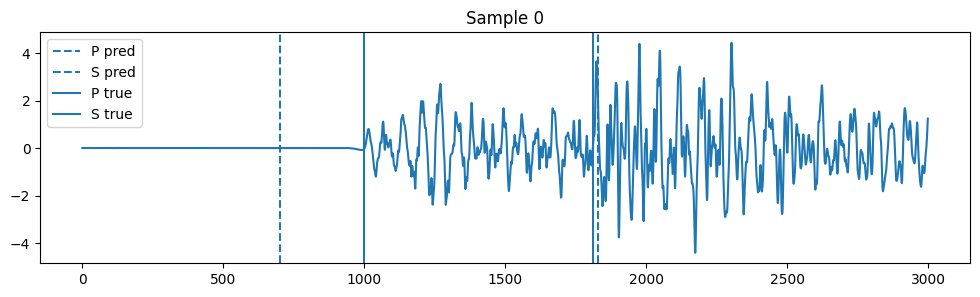


Sample 1
Detection Prob: 1.0000
P pred: 809, P true: 800
S pred: 1385, S true: 1336


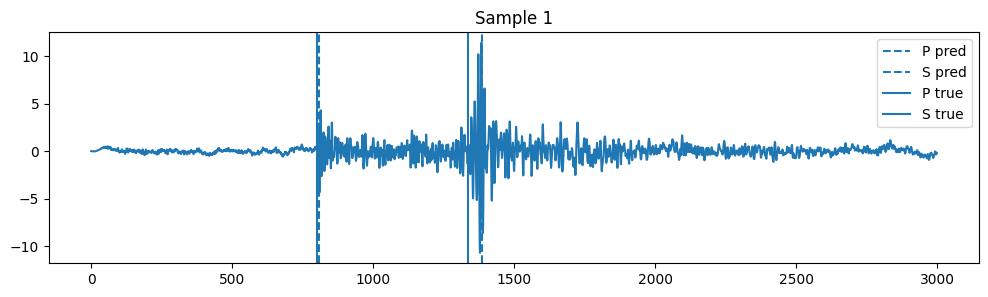


Sample 2
Detection Prob: 1.0000
P pred: 902, P true: 899
S pred: 958, S true: 945


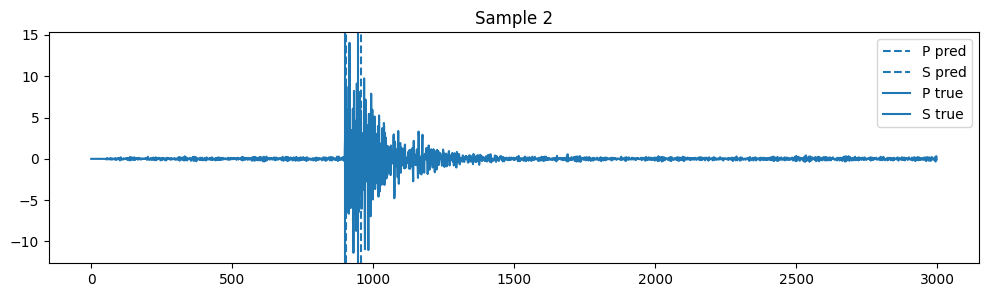


Sample 3
Detection Prob: 1.0000
P pred: 603, P true: 600
S pred: 937, S true: 930


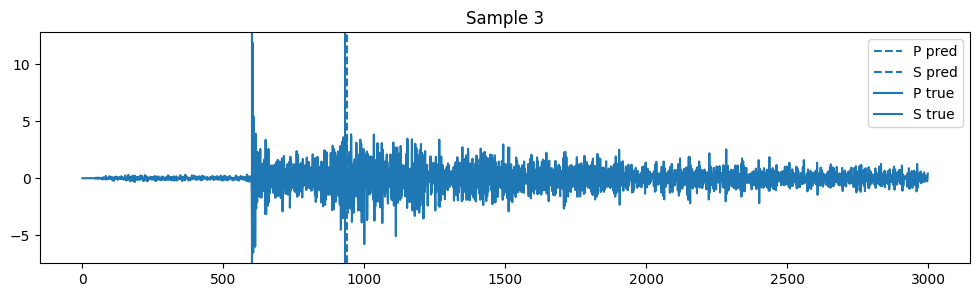


Sample 4
Detection Prob: 1.0000
P pred: 695, P true: 900
S pred: 1807, S true: 1782


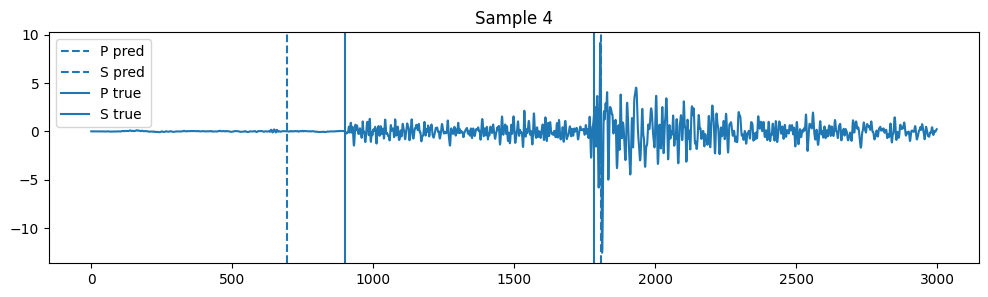


Sample 5
Detection Prob: 1.0000
P pred: 699, P true: 700
S pred: 1891, S true: 2400


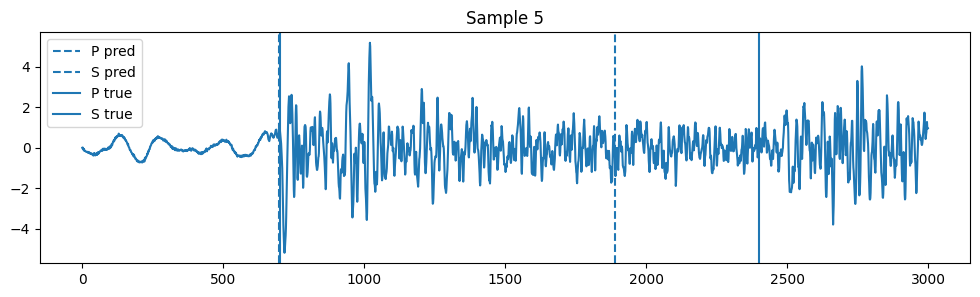

In [1]:
import torch
import torch.nn as nn
import numpy as np
import seisbench.data as sbd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_score, recall_score, roc_auc_score, average_precision_score

from models import ResidualBlock

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# LOAD DATASET
# =========================
dataset = sbd.STEAD()
metadata = dataset.metadata

# ---- FILTER (NO RESET INDEX) ----
eq_mask = (
    (metadata["trace_category"] == "earthquake_local") &
    (metadata["trace_p_arrival_sample"].notna()) &
    (metadata["trace_s_arrival_sample"].notna()) &
    (metadata["trace_p_arrival_sample"] < 3000) &
    (metadata["trace_s_arrival_sample"] < 3000)
)

noise_mask = metadata["trace_category"] == "noise"
filtered_metadata = metadata[eq_mask | noise_mask]

# ---- RANDOM SAMPLING EVERY RUN ----
test_metadata = filtered_metadata.sample(n=20)  # take 20 → ensure enough EQ samples

# =========================
# FEATURES
# =========================
def compute_sta_lta(wf, sta=50, lta=500):
    energy = np.sum(wf**2, axis=0)
    sta_vals = np.convolve(energy, np.ones(sta)/sta, mode="same")
    lta_vals = np.convolve(energy, np.ones(lta)/lta, mode="same")
    ratio = sta_vals / (lta_vals + 1e-8)
    return (ratio / (np.max(ratio)+1e-8)).astype(np.float32)

def gaussian_pick(arrival, sigma):
    t = np.arange(3000)
    return np.exp(-(t-arrival)**2/(2*sigma**2)).astype(np.float32)

# =========================
# DATASET
# =========================
class Phase2Dataset(Dataset):
    def __init__(self, dataset, metadata):
        self.dataset = dataset
        self.metadata = metadata

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        meta = self.metadata.iloc[idx]
        real_idx = meta.name

        wf = self.dataset.get_waveforms([real_idx])[0][:, :3000].astype(np.float32)

        wf = wf - wf.mean(axis=1, keepdims=True)
        wf = wf / (wf.std(axis=1, keepdims=True) + 1e-6)

        y_det = 1.0 if meta["trace_category"] == "earthquake_local" else 0.0

        sta = compute_sta_lta(wf)
        sta = (sta - sta.mean()) / (sta.std() + 1e-6)
        sta = np.clip(sta, -3, 3)

        x = np.vstack([wf, 0.3 * sta]).astype(np.float32)

        if y_det == 1:
            p = int(meta["trace_p_arrival_sample"])
            s = int(meta["trace_s_arrival_sample"])
            y_p = gaussian_pick(p, 8)
            y_s = gaussian_pick(s, 20)
        else:
            y_p = np.zeros(3000, dtype=np.float32)
            y_s = np.zeros(3000, dtype=np.float32)

        return (
            torch.from_numpy(x),
            torch.tensor([y_det], dtype=torch.float32),
            torch.from_numpy(y_p),
            torch.from_numpy(y_s)
        )

# =========================
# MODEL
# =========================
class Phase2MultiTaskTCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_conv = nn.Conv1d(4, 32, 1)

        dilations = [1,2,4,8,16,32,64,128]
        self.blocks = nn.Sequential(*[ResidualBlock(32,5,d) for d in dilations])

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32,1)

        self.p_head = nn.Sequential(
            nn.Conv1d(32,32,3,padding=1),
            nn.ReLU(),
            nn.Conv1d(32,1,1)
        )

        self.s_head = nn.Sequential(
            nn.Conv1d(32,32,7,padding=3),
            nn.ReLU(),
            nn.Conv1d(32,1,1)
        )

    def forward(self, x):
        x = self.input_conv(x)
        f = self.blocks(x)

        det = self.fc(self.pool(f).squeeze(-1))
        p = self.p_head(f).squeeze(1)
        s = self.s_head(f).squeeze(1)

        return det, p, s

# =========================
# LOAD MODEL
# =========================
model = Phase2MultiTaskTCN()
ckpt = torch.load("phase2_model.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()

# =========================
# LOADER
# =========================
loader = DataLoader(Phase2Dataset(dataset, test_metadata), batch_size=4)

# =========================
# METRICS
# =========================
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for x, y_det, _, _ in loader:
        x = x.float().to(device)
        y_det = y_det.to(device)

        det_out, _, _ = model(x)

        prob = torch.sigmoid(det_out).squeeze(1)
        pred = (prob > 0.5).float()

        all_probs.extend(prob.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y_det.squeeze(1).cpu().numpy())

print("\n=== METRICS ===")
print("Precision:", precision_score(all_labels, all_preds))
print("Recall:", recall_score(all_labels, all_preds))
print("ROC-AUC:", roc_auc_score(all_labels, all_probs))
print("PR-AUC:", average_precision_score(all_labels, all_probs))

# =========================
# PLOT EXACTLY 6 EARTHQUAKE SAMPLES
# =========================
print("\n=== RANDOM SAMPLE VISUALIZATION ===")

count = 0

for x, y_det, y_p, y_s in loader:
    x = x.float().to(device)

    with torch.no_grad():
        det, p_out, s_out = model(x)

    prob = torch.sigmoid(det)

    for i in range(len(x)):
        if count >= 6:
            break

        # only earthquake samples
        if y_det[i].item() == 0:
            continue

        wf = x[i,0].cpu().numpy()

        p_pred = torch.argmax(p_out[i]).item()
        s_pred = torch.argmax(s_out[i]).item()

        p_true = torch.argmax(y_p[i]).item()
        s_true = torch.argmax(y_s[i]).item()

        print(f"\nSample {count}")
        print(f"Detection Prob: {prob[i].item():.4f}")
        print(f"P pred: {p_pred}, P true: {p_true}")
        print(f"S pred: {s_pred}, S true: {s_true}")

        plt.figure(figsize=(12,3))
        plt.plot(wf)

        plt.axvline(p_pred, linestyle="--", label="P pred")
        plt.axvline(s_pred, linestyle="--", label="S pred")

        plt.axvline(p_true, linestyle="-", label="P true")
        plt.axvline(s_true, linestyle="-", label="S true")

        plt.legend()
        plt.title(f"Sample {count}")
        plt.show()

        count += 1

    if count >= 6:
        break